### Variational Autoencoder for CelebA Dataset

VAE for Celebrity Face Generation

⚠️ ERROR: Folder not found: path/to/celeba/images

Please update CELEB_DATA_FOLDER to point to your celebrity images folder.

For example:
  CELEB_DATA_FOLDER = 'C:/datasets/celeba/img_align_celeba'
  CELEB_DATA_FOLDER = './data/celeba/images'

You can download CelebA dataset from:
  https://www.kaggle.com/datasets/jessicali9530/celeba-dataset

Falling back to MNIST for demonstration...
Using MNIST dataset instead

Building VAE model...

✓ Model built successfully!
Model: "model_15"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 encoder_conv_0 (Conv2D)        (None, 28, 28, 32)   320         ['encoder_input[

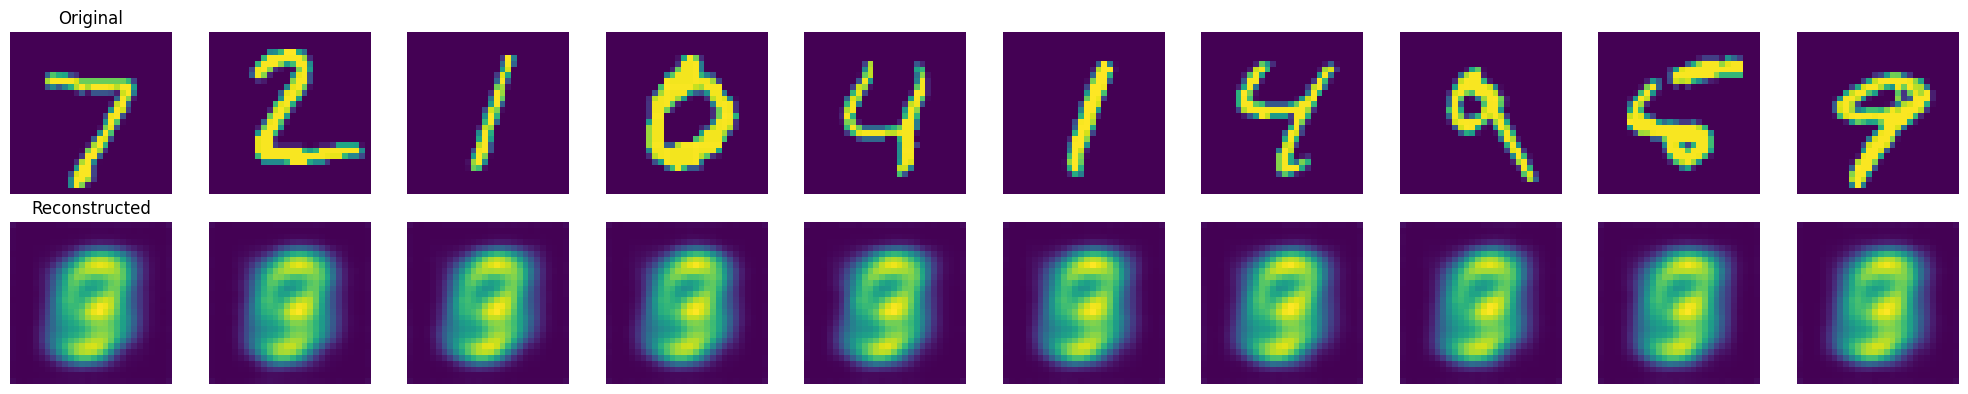


Generating new celebrity faces...


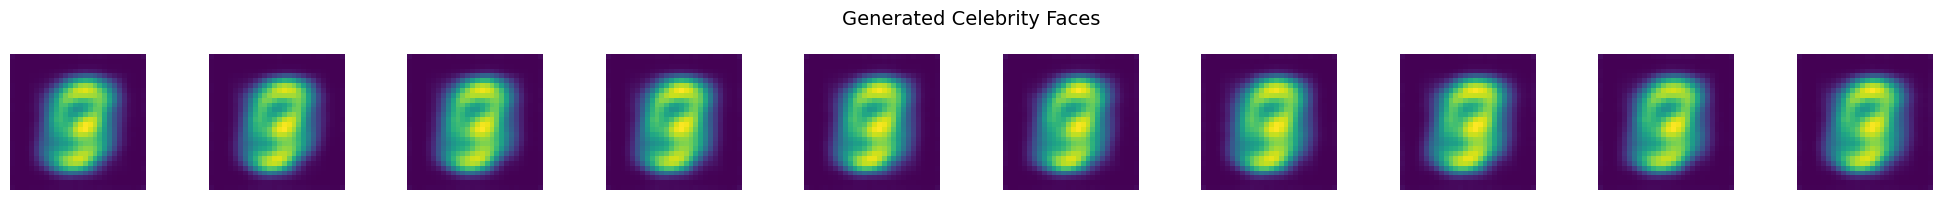


✓ Training complete!


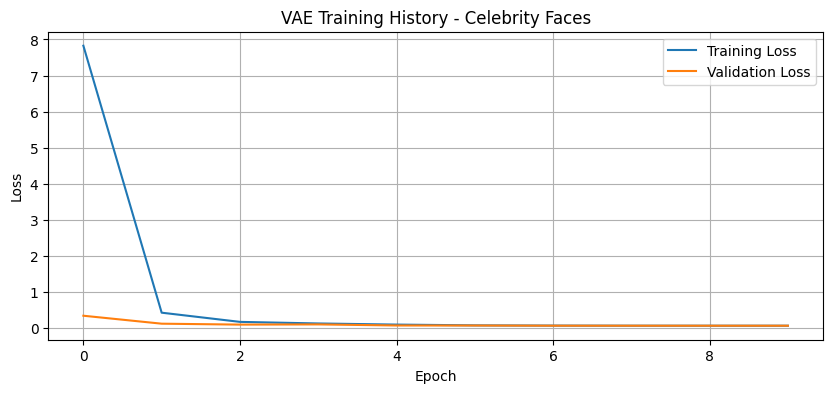

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    Input, Conv2D, Flatten, Dense, Conv2DTranspose, Reshape,
    Lambda, Activation, BatchNormalization, LeakyReLU, Dropout,
)
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import os

# Variational Autoencoder class
class VariationalAutoencoder:
    def __init__(
        self,
        input_dim,
        encoder_conv_filters,
        encoder_conv_kernel_size,
        encoder_conv_strides,
        decoder_conv_t_filters,
        decoder_conv_t_kernel_size,
        decoder_conv_t_strides,
        z_dim,
        use_dropout=False,
    ):
        self.name = "variational_autoencoder"
        
        # store parameters
        self.input_dim = input_dim  # size of input image
        self.encoder_conv_filters = encoder_conv_filters  # encoder conv layers depth
        self.encoder_conv_kernel_size = encoder_conv_kernel_size  # encoder conv kernel size
        self.encoder_conv_strides = encoder_conv_strides  # encoder conv strides
        self.decoder_conv_t_filters = decoder_conv_t_filters  # decoder conv transpose layers depth
        self.decoder_conv_t_kernel_size = decoder_conv_t_kernel_size  # decoder conv kernel size
        self.decoder_conv_t_strides = decoder_conv_t_strides  # decoder conv strides
        self.z_dim = z_dim  # dimension of latent space
        self.use_dropout = use_dropout  # use dropouts or not
        
        # number of layers
        self.n_layers_encoder = len(encoder_conv_filters)  # number of encoder conv layers
        self.n_layers_decoder = len(decoder_conv_t_filters)  # number of decoder conv transpose layers
        
        self._build()  # Build the model

    # BUILD THE FULL VAE MODEL
    def _build(self):
        ### THE ENCODER ###
        # A model that takes an input image and encodes it into the 2D latent space,
        # by sampling a point from the normal distribution defined by mu and log_var.
        encoder_input = Input(shape=self.input_dim, name="encoder_input")
        x = encoder_input
        
        for i in range(self.n_layers_encoder):
            conv_layer = Conv2D(
                filters=self.encoder_conv_filters[i],
                kernel_size=self.encoder_conv_kernel_size[i],
                strides=self.encoder_conv_strides[i],
                padding="same",
                name="encoder_conv_" + str(i),
            )
            x = conv_layer(x)
            x = BatchNormalization()(x)
            x = LeakyReLU()(x)
            if self.use_dropout:
                x = Dropout(rate=0.25)(x)
        
        shape_before_flattening = K.int_shape(x)[1:]
        x = Flatten()(x)
        
        self.mu = Dense(self.z_dim, name="mu")(x)
        self.log_var = Dense(self.z_dim, name="log_var")(x)
        
        # We choose to map to the logarithm of the variance, as this can take any real
        # number. In the range (−inf, inf), matching the natural output range from a
        # neural network unit, whereas variance values are always positive.
        self.encoder_mu_log_var = Model(encoder_input, (self.mu, self.log_var))
        
        ### Latent space sampling ###
        # Now, since we are sampling a random point from an area around mu, the decoder
        # must ensure that all points in the same neighborhood produce very similar images when
        # decoded, so that the reconstruction loss remains small.
        def sampling(args):
            mu, log_var = args
            epsilon = K.random_normal(shape=K.shape(mu), mean=0.0, stddev=1.0)
            return mu + K.exp(log_var / 2) * epsilon
        
        encoder_output = Lambda(sampling, name="encoder_output")(
            [self.mu, self.log_var]
        )
        
        self.encoder = Model(encoder_input, encoder_output)
        
        ### THE DECODER ###
        # A model that takes a point in the latent space and decodes it into the original image domain.
        decoder_input = Input(shape=(self.z_dim,), name="decoder_input")
        x = Dense(np.prod(shape_before_flattening))(decoder_input)
        x = Reshape(shape_before_flattening)(x)
        
        for i in range(self.n_layers_decoder):
            conv_t_layer = Conv2DTranspose(
                filters=self.decoder_conv_t_filters[i],
                kernel_size=self.decoder_conv_t_kernel_size[i],
                strides=self.decoder_conv_t_strides[i],
                padding="same",
                name="decoder_conv_t_" + str(i),
            )
            x = conv_t_layer(x)
            
            # condition for not having bn-leakyrelu-dropout at last layer
            if i < self.n_layers_decoder - 1:
                x = BatchNormalization()(x)
                x = LeakyReLU()(x)
                if self.use_dropout:
                    x = Dropout(rate=0.25)(x)
            else:
                x = Activation("sigmoid")(x)
        
        decoder_output = x
        self.decoder = Model(decoder_input, decoder_output)
        
        ### THE FULL MODEL ###
        # Connect encoder and decoder to create the full VAE
        model_input = encoder_input
        model_output = self.decoder(encoder_output)
        self.model = Model(model_input, model_output)
        
        ### LOSS FUNCTION ###
        # VAE loss = Reconstruction loss + KL divergence loss
        # We need to add the KL loss as a custom layer to track mu and log_var properly
        
        # Add KL divergence loss to the model
        kl_loss = -0.5 * K.sum(1 + self.log_var - K.square(self.mu) - K.exp(self.log_var), axis=-1)
        kl_loss = K.mean(kl_loss)
        self.model.add_loss(kl_loss)
        
        # Compile with just reconstruction loss (KL loss is already added via add_loss)
        self.model.compile(
            optimizer=Adam(learning_rate=0.0005),
            loss='mse'  # Reconstruction loss
        )
    
    def train(self, x_train, x_test, epochs=10, batch_size=32):
        """Train the VAE model"""
        history = self.model.fit(
            x_train,
            x_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(x_test, x_test),
            verbose=1
        )
        return history
    
    def train_with_generator(self, train_generator, validation_generator, epochs=10, steps_per_epoch=100):
        """Train the VAE model using data generators"""
        history = self.model.fit(
            train_generator,
            epochs=epochs,
            steps_per_epoch=steps_per_epoch,
            validation_data=validation_generator,
            validation_steps=50,
            verbose=1
        )
        return history
    
    ### IMAGE RECONSTRUCTION ###
    def reconstruct(self, data, n=10):
        """Visualize original and reconstructed images"""
        reconstructed = self.model.predict(data[:n], verbose=0)
        
        plt.figure(figsize=(20, 4))
        for i in range(n):
            # Original
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(data[i].squeeze())
            ax.axis("off")
            if i == 0:
                ax.set_title("Original", fontsize=12)
            
            # Reconstructed
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(reconstructed[i].squeeze())
            ax.axis("off")
            if i == 0:
                ax.set_title("Reconstructed", fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    ### IMAGE GENERATION ###
    def generate(self, n=10):
        """Generate new images from random latent space samples"""
        # Generate new faces from latent space
        samples = np.random.normal(size=(n, self.z_dim))
        generated = self.decoder.predict(samples, verbose=0)
        
        plt.figure(figsize=(20, 2))
        for i in range(n):
            ax = plt.subplot(1, n, i + 1)
            plt.imshow(generated[i].squeeze())
            ax.axis("off")
        plt.suptitle("Generated Celebrity Faces", fontsize=14)
        plt.tight_layout()
        plt.show()


# ============================================================================
# HELPER FUNCTIONS FOR LOADING CELEBA DATA
# ============================================================================

def load_celeba_data(data_folder, target_size=(128, 128), max_images=10000):
    """
    Load CelebA images from a folder
    
    Args:
        data_folder: Path to folder containing celebrity images
        target_size: Resize images to this size (width, height)
        max_images: Maximum number of images to load
    
    Returns:
        x_train, x_test: Training and test datasets
    """
    from tensorflow.keras.preprocessing import image
    import glob
    
    print(f"Loading images from: {data_folder}")
    
    # Get all image files
    image_files = glob.glob(os.path.join(data_folder, "*.jpg"))
    image_files += glob.glob(os.path.join(data_folder, "*.png"))
    
    if len(image_files) == 0:
        raise ValueError(f"No images found in {data_folder}")
    
    # Limit number of images
    image_files = image_files[:max_images]
    print(f"Found {len(image_files)} images")
    
    # Load and preprocess images
    images = []
    for i, img_path in enumerate(image_files):
        if i % 1000 == 0:
            print(f"Loading image {i}/{len(image_files)}")
        
        try:
            img = image.load_img(img_path, target_size=target_size)
            img_array = image.img_to_array(img)
            img_array = img_array / 255.0  # Normalize to [0, 1]
            images.append(img_array)
        except:
            print(f"Error loading {img_path}, skipping...")
            continue
    
    images = np.array(images)
    print(f"Loaded {len(images)} images successfully")
    
    # Split into train and test
    split_idx = int(0.8 * len(images))
    x_train = images[:split_idx]
    x_test = images[split_idx:]
    
    return x_train, x_test


def create_data_generator(data_folder, target_size=(128, 128), batch_size=32):
    """
    Create a data generator for loading images on-the-fly
    This is memory efficient for large datasets
    
    Args:
        data_folder: Path to folder containing celebrity images
        target_size: Resize images to this size
        batch_size: Batch size for training
    
    Returns:
        train_generator, validation_generator
    """
    datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2  # 20% for validation
    )
    
    train_generator = datagen.flow_from_directory(
        data_folder,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='input',  # Important: for autoencoders, input = output
        subset='training'
    )
    
    validation_generator = datagen.flow_from_directory(
        data_folder,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='input',
        subset='validation'
    )
    
    return train_generator, validation_generator


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    # ===================================================================
    # OPTION 1: Load all images into memory (for smaller datasets)
    # ===================================================================
    print("="*70)
    print("VAE for Celebrity Face Generation")
    print("="*70)
    
    # TODO: Update this path to your CelebA dataset folder
    CELEB_DATA_FOLDER = "path/to/celeba/images"  # <-- CHANGE THIS!
    
    # Check if the folder exists
    if not os.path.exists(CELEB_DATA_FOLDER):
        print(f"\n⚠️ ERROR: Folder not found: {CELEB_DATA_FOLDER}")
        print("\nPlease update CELEB_DATA_FOLDER to point to your celebrity images folder.")
        print("\nFor example:")
        print("  CELEB_DATA_FOLDER = 'C:/datasets/celeba/img_align_celeba'")
        print("  CELEB_DATA_FOLDER = './data/celeba/images'")
        print("\nYou can download CelebA dataset from:")
        print("  https://www.kaggle.com/datasets/jessicali9530/celeba-dataset")
        print("="*70)
        
        # Fall back to MNIST for demonstration
        print("\nFalling back to MNIST for demonstration...")
        from tensorflow.keras.datasets import mnist
        (x_train, _), (x_test, _) = mnist.load_data()
        x_train = x_train.astype('float32') / 255.0
        x_test = x_test.astype('float32') / 255.0
        x_train = np.expand_dims(x_train, -1)
        x_test = np.expand_dims(x_test, -1)
        INPUT_DIM = (28, 28, 1)
        print("Using MNIST dataset instead")
    else:
        # Load CelebA data
        print("\nLoading CelebA dataset...")
        x_train, x_test = load_celeba_data(
            CELEB_DATA_FOLDER,
            target_size=(128, 128),
            max_images=10000  # Adjust based on your memory
        )
        INPUT_DIM = (128, 128, 3)
        print(f"Training data shape: {x_train.shape}")
        print(f"Test data shape: {x_test.shape}")
    
    # ===================================================================
    # OPTION 2: Use data generators (for larger datasets)
    # ===================================================================
    # Uncomment this section if you have a large dataset and want to use generators
    # train_generator, validation_generator = create_data_generator(
    #     CELEB_DATA_FOLDER,
    #     target_size=(128, 128),
    #     batch_size=32
    # )
    # INPUT_DIM = (128, 128, 3)
    
    # Create VAE instance
    print("\nBuilding VAE model...")
    
    if INPUT_DIM == (28, 28, 1):  # MNIST configuration
        vae = VariationalAutoencoder(
            input_dim=INPUT_DIM,
            encoder_conv_filters=[32, 64, 64, 64],
            encoder_conv_kernel_size=[3, 3, 3, 3],
            encoder_conv_strides=[1, 2, 2, 1],
            decoder_conv_t_filters=[64, 64, 32, 1],
            decoder_conv_t_kernel_size=[3, 3, 3, 3],
            decoder_conv_t_strides=[1, 2, 2, 1],
            z_dim=200,
            use_dropout=True
        )
    else:  # CelebA configuration (128x128x3)
        vae = VariationalAutoencoder(
            input_dim=INPUT_DIM,
            encoder_conv_filters=[32, 64, 128, 256],
            encoder_conv_kernel_size=[5, 5, 3, 3],
            encoder_conv_strides=[2, 2, 2, 2],
            decoder_conv_t_filters=[128, 64, 32, 3],
            decoder_conv_t_kernel_size=[3, 5, 5, 5],
            decoder_conv_t_strides=[2, 2, 2, 2],
            z_dim=200,
            use_dropout=True
        )
    
    print("\n✓ Model built successfully!")
    print(vae.model.summary())
    
    # Train the model
    print("\n" + "="*70)
    print("Starting training...")
    print("="*70)
    
    # Option 1: Train with loaded data
    history = vae.train(x_train, x_test, epochs=10, batch_size=32)
    
    # Option 2: Train with generators (uncomment if using generators)
    # history = vae.train_with_generator(
    #     train_generator,
    #     validation_generator,
    #     epochs=10,
    #     steps_per_epoch=100
    # )
    
    # Visualize results
    print("\n" + "="*70)
    print("Visualizing reconstructions...")
    print("="*70)
    vae.reconstruct(x_test, n=10)
    
    print("\n" + "="*70)
    print("Generating new celebrity faces...")
    print("="*70)
    vae.generate(n=10)
    
    print("\n Training complete!")
    
    # Plot training history
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Training History - Celebrity Faces')
    plt.legend()
    plt.grid(True)
    plt.show()

### Variational Autoencoder (VAE) on Fashion MNIST for Latent Space Visualization

Epoch 1/10
469/469 [==============================] - 12s 24ms/step - loss: 65.7129 - reconstruction_loss: 19.4292 - kl_loss: 0.5042
Epoch 2/10
469/469 [==============================] - 12s 25ms/step - loss: 6.6419 - reconstruction_loss: 6.6307 - kl_loss: 2.9535e-05
Epoch 3/10
469/469 [==============================] - 12s 25ms/step - loss: 6.6081 - reconstruction_loss: 6.6138 - kl_loss: 3.1617e-05
Epoch 4/10
469/469 [==============================] - 11s 24ms/step - loss: 6.6034 - reconstruction_loss: 6.6104 - kl_loss: 2.7185e-05
Epoch 5/10
469/469 [==============================] - 11s 24ms/step - loss: 6.6193 - reconstruction_loss: 6.6088 - kl_loss: 2.1597e-05
Epoch 6/10
469/469 [==============================] - 11s 24ms/step - loss: 6.6027 - reconstruction_loss: 6.6082 - kl_loss: 1.5610e-05
Epoch 7/10
469/469 [==============================] - 11s 24ms/step - loss: 6.6099 - reconstruction_loss: 6.6068 - kl_loss: 1.0445e-05
Epoch 8/10
469/469 [==============================] - 11s

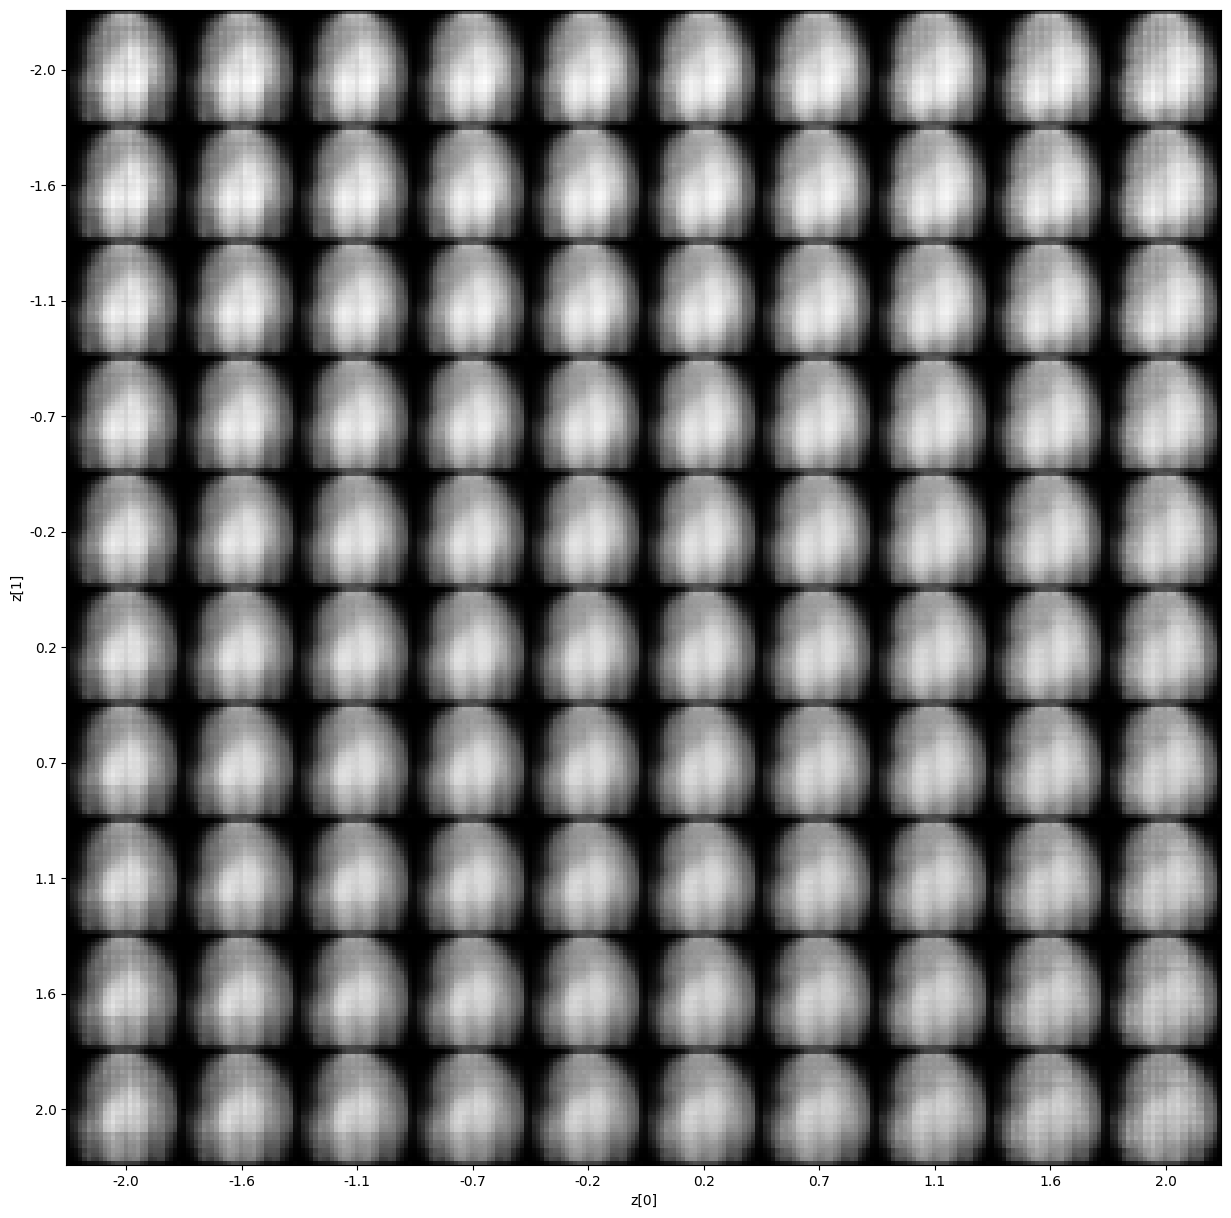

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 8491795867214787535
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 2238133044
locality {
  bus_id: 1
  links {
  }
}
incarnation: 17453954385339558507
physical_device_desc: "device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5"
xla_global_id: 416903419
]
